# Preprocessing



## Import Libraries

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
#tensorflow is for build neural network architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import layers
from tensorflow import keras

from sklearn.metrics import classification_report #for calculating metric performance of model

## MNIST dataset

-  MNIST is a collection of handwritten digits ranging from the number 0 to 9.

-  It has a training set of 60,000 images and 10,000 test images that are classified into corresponding categories or labels.

-  In Keras the MNIST dataset is preloaded in the form of four Numpy arrays.

-  To use the MNIST dataset in Keras, an API is provided to download and extract images and labels automatically.

In [2]:
# Load dataset and put into train-set and test-set
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


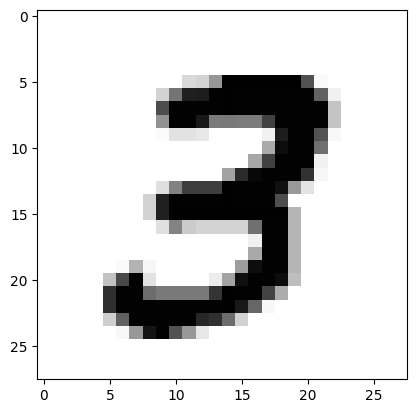

In [3]:
# Display sample image
plt.imshow(x_train[7], cmap=plt.cm.binary)

In [4]:
# View the labels
print(y_train[7])

3


In [5]:
# View number of dimensions of tensor

print(x_train.ndim)

3


## Data Normalization

-  The MNIST images of 28×28 pixels are represented as an array of numbers whose values range from [0, 255] of type uint8.
-  It is usual to scale the input values of neural networks to certain ranges.
-  In this example, the input values should be scaled to values of type float32 within the interval [0, 1].

In [6]:
# scale the input values to type float32

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [7]:
# scale the input values within the interval [0, 1]

x_train_scaled = x_train / 255
x_test_scaled = x_test / 255

-  To facilitate the entry of data into our neural network we must make a transformation of the tensor (image) from 2 dimensions (2D) to a vector of 1 dimension (1D).
-  That is, the matrix of 28×28 numbers can be represented by a vector (array) of 784 numbers (concatenating row by row), which is the format that accepts as input a densely connected neural network.
-  In Python, converting every image of the MNIST dataset to a vector with 784 components.

In [8]:
x_train_1d = x_train_scaled.reshape(60000, 784)
x_test_1d = x_test_scaled.reshape(10000, 784)

In [9]:
print(f"x_train_1d shape: {x_train_1d.shape}")
print(f"x_test_1d shape: {x_test_1d.shape}")

x_train_1d shape: (60000, 784)
x_test_1d shape: (10000, 784)


In [10]:
from tensorflow.keras.utils import to_categorical

y_train_categorical = to_categorical(y_train, num_classes=10)
y_test_categorical = to_categorical(y_test, num_classes=10)

# Modeling ANN

## Define Model Architecture

In [13]:
# design ANN architecture
model = Sequential()
model.add(layers.Input(shape=(x_train_1d.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(10, activation='softmax'))

# complie model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,018 (207.10 KB)

 Trainable params: 53,018 (207.10 KB)

 Non-trainable params: 0 (0.00 B)

## Running Model

In [16]:
history = model.fit(x_train_1d, y_train, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9861 - loss: 0.0462 - val_accuracy: 0.9695 - val_loss: 0.1074
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9885 - loss: 0.0408 - val_accuracy: 0.9691 - val_loss: 0.1099
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9891 - loss: 0.0372 - val_accuracy: 0.9694 - val_loss: 0.1144
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9900 - loss: 0.0324 - val_accuracy: 0.9695 - val_loss: 0.1128
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9922 - loss: 0.0264 - val_accuracy: 0.9693 - val_loss: 0.1238
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9929 - loss: 0.0242 - val_accuracy: 0.9688 - val_loss: 0.1195
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9938 - loss: 0.0212 - val_accuracy: 0.9696 - val_loss: 0.1240
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9945 - loss: 0.0199 - val_accuracy: 0.

## Evaluate and Save Model

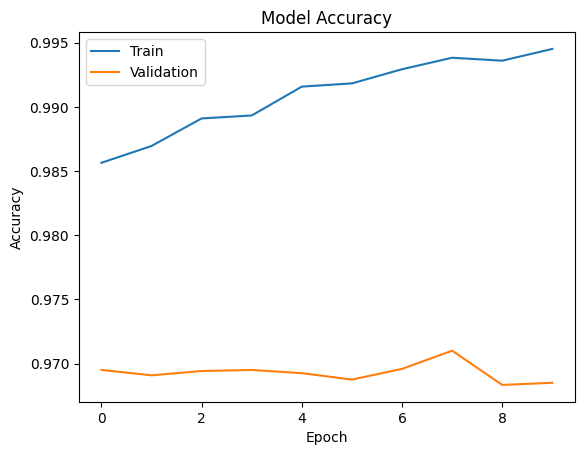

In [17]:
# plot historical accuracy of model
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

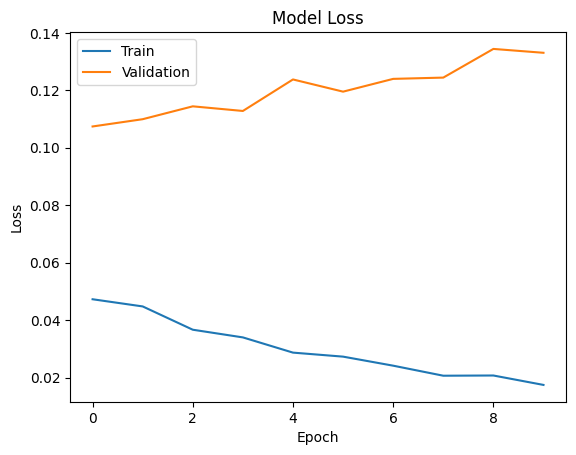

In [18]:
# plot historical loss of model
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [19]:
# calculate metric performance
y_pred = model.predict(x_test_1d)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.94      0.97      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.95      0.96       892
           6       0.98      0.97      0.98       958
           7       0.96      0.97      0.96      1028
           8       0.97      0.96      0.96       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



## Conclusion

We developed an Artificial Neural Network (ANN) model to recognize digit images from the MNIST dataset. The model achieved an accuracy of 0.97, with F1-scores for each label ranging from 0.96 to 0.99. These results indicate robust data classification and accurate label recognition, with no signs of overfitting.